In [1]:
import sys
from pathlib import Path

# Locate project root by walking up until .git is found, then make
# config.py importable regardless of Jupyter's working directory.
_root = Path.cwd().resolve()
while not (_root / ".git").exists():
    if _root == _root.parent:
        raise FileNotFoundError("Could not locate project root (.git not found)")
    _root = _root.parent
sys.path.insert(0, str(_root))

from config import RAW_DATASET_PATH, DATA_PROCESSED
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(RAW_DATASET_PATH)
print(f"Loaded {len(df):,} rows")

Loaded 100,000 rows


In [2]:
# Filter to diabetic cohort

df = df[df['diabetes'] == 1].copy()
print(f"Diabetic cohort: {len(df):,} rows")

Diabetic cohort: 62,232 rows


In [3]:
# Convert admission and discharge dates to datetime
df['admission_date'] = pd.to_datetime( 
    df['admission_date'], 
    dayfirst=True ) 

df['discharge_date'] = pd.to_datetime(
    df['discharge_date'],
    dayfirst=True )

In [4]:
df['admission_date'] = pd.to_datetime(df['admission_date'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])
df['length_of_stay'] = (df['discharge_date'] - df['admission_date']).dt.days
df = df.drop(columns=['admission_date', 'discharge_date'])
print(f"length_of_stay range: {df['length_of_stay'].min()} to {df['length_of_stay'].max()}")

length_of_stay range: 1 to 14


In [5]:
cohort_missing = df['medications'].isnull().sum()
print(f"Missing medications WITHIN the diabetic cohort: {cohort_missing}")
if cohort_missing == 0:
    print("The 13,878 missing values documented in the thesis fall entirely OUTSIDE the diabetic "
          "cohort. The fillna('Unknown') step below is a defensive no-op for this dataset - keep it "
          "for robustness against future data, but the 'Unknown' category will not appear in the "
          "trained encoder, and the API must not silently invent it at inference time.")

Missing medications WITHIN the diabetic cohort: 0
The 13,878 missing values documented in the thesis fall entirely OUTSIDE the diabetic cohort. The fillna('Unknown') step below is a defensive no-op for this dataset - keep it for robustness against future data, but the 'Unknown' category will not appear in the trained encoder, and the API must not silently invent it at inference time.


In [6]:
df['medications'] = df['medications'].fillna('Unknown')

In [7]:
categorical_cols = ['sex', 'smoking_status', 'alcohol_use', 'primary_diagnosis', 'medications']

unexpected_missing = {c: df[c].isnull().sum() for c in categorical_cols if df[c].isnull().sum() > 0}
if unexpected_missing:
    raise ValueError(
        f"Unexpected missing values found in categorical columns: {unexpected_missing}. "
        "Investigate before encoding - do not let LabelEncoder silently treat NaN as a valid category."
    )
print("No unexpected missing values. Safe to encode.")

No unexpected missing values. Safe to encode.


In [8]:
from config import MODELS_DIR, ENCODERS_PATH
import joblib

encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col}: {len(le.classes_)} categories -> {list(le.classes_)}")

MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(encoders, ENCODERS_PATH)
print(f"\nSaved encoders to {ENCODERS_PATH}")

sex: 3 categories -> ['Female', 'Male', 'Other']
smoking_status: 3 categories -> ['Current', 'Former', 'Never']
alcohol_use: 3 categories -> ['Never', 'Occasional', 'Regular']
primary_diagnosis: 2 categories -> ['Diabetes', 'Diabetes;Hypertension']
medications: 20 categories -> ['DPP4 inhibitor', 'DPP4 inhibitor;ACE inhibitor', 'DPP4 inhibitor;Beta blocker', 'DPP4 inhibitor;Calcium channel blocker', 'DPP4 inhibitor;Thiazide', 'Insulin', 'Insulin;ACE inhibitor', 'Insulin;Beta blocker', 'Insulin;Calcium channel blocker', 'Insulin;Thiazide', 'Metformin', 'Metformin;ACE inhibitor', 'Metformin;Beta blocker', 'Metformin;Calcium channel blocker', 'Metformin;Thiazide', 'Sulfonylurea', 'Sulfonylurea;ACE inhibitor', 'Sulfonylurea;Beta blocker', 'Sulfonylurea;Calcium channel blocker', 'Sulfonylurea;Thiazide']

Saved encoders to C:\Users\hamna\Desktop\MediAlert\models\label_encoders.pkl


In [9]:
assert df['diabetes'].nunique() == 1, "Expected diabetes column to be constant after cohort filter"
df = df.drop(columns=['diabetes'])
print(f"Final shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Final shape: (62232, 20)
Columns: ['patient_id', 'age', 'sex', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol', 'hdl', 'ldl', 'glucose', 'creatinine', 'hemoglobin', 'wbc', 'smoking_status', 'alcohol_use', 'hypertension', 'primary_diagnosis', 'medications', 'readmission_30', 'length_of_stay']


In [10]:
assert df.isnull().sum().sum() == 0, "Missing values remain after preprocessing!"
print("Verified: no missing values, no silent NaN-as-category encoding.")

DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
out_path = DATA_PROCESSED / "diabetic_cohort_preprocessed.csv"
df.to_csv(out_path, index=False)
print(f"Saved to {out_path}")

Verified: no missing values, no silent NaN-as-category encoding.


Saved to C:\Users\hamna\Desktop\MediAlert\data\processed\diabetic_cohort_preprocessed.csv


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from config import RAW_DATASET_PATH

# Reload raw data with dates intact for this analysis
df_analysis = pd.read_csv(RAW_DATASET_PATH)
df_analysis = df_analysis[df_analysis['diabetes'] == 1].copy()

df_analysis['admission_date'] = pd.to_datetime(df_analysis['admission_date'], dayfirst=True)
df_analysis['discharge_date'] = pd.to_datetime(df_analysis['discharge_date'], dayfirst=True)
df_analysis['length_of_stay'] = (df_analysis['discharge_date'] - df_analysis['admission_date']).dt.days

print("Length of stay distribution:")
print(df_analysis['length_of_stay'].describe().round(2))
print(f"\nReadmitted patients: {df_analysis['readmission_30'].sum():,}")
print(f"Non-readmitted: {(df_analysis['readmission_30'] == 0).sum():,}")

Length of stay distribution:
count    62232.00
mean         7.50
std          4.02
min          1.00
25%          4.00
50%          7.00
75%         11.00
max         14.00
Name: length_of_stay, dtype: float64

Readmitted patients: 32,609
Non-readmitted: 29,623


In [12]:
# Group by length of stay and calculate readmission rate
los_summary = df_analysis.groupby('length_of_stay').agg(
    total_patients=('readmission_30', 'count'),
    readmitted=('readmission_30', 'sum')
).reset_index()

los_summary['readmission_rate'] = (
    los_summary['readmitted'] / los_summary['total_patients'] * 100
).round(2)

print("Readmission rate by length of stay (days):")
print(los_summary.to_string(index=False))

Readmission rate by length of stay (days):
 length_of_stay  total_patients  readmitted  readmission_rate
              1            4435        2371             53.46
              2            4378        2313             52.83
              3            4366        2270             51.99
              4            4465        2354             52.72
              5            4485        2406             53.65
              6            4506        2275             50.49
              7            4482        2350             52.43
              8            4439        2312             52.08
              9            4478        2324             51.90
             10            4515        2364             52.36
             11            4342        2264             52.14
             12            4493        2379             52.95
             13            4482        2291             51.12
             14            4366        2336             53.50


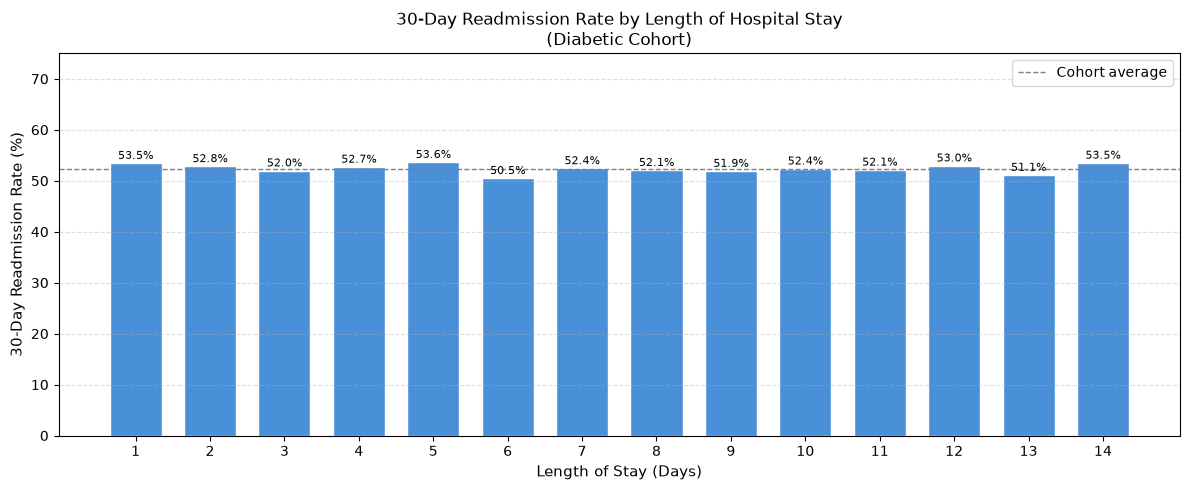

Chart saved.


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(
    los_summary['length_of_stay'],
    los_summary['readmission_rate'],
    color=['#d94f3d' if r > 55 else '#4a90d9' for r in los_summary['readmission_rate']],
    edgecolor='white',
    width=0.7
)

# Annotate bars
for bar, rate in zip(bars, los_summary['readmission_rate']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{rate:.1f}%',
        ha='center', va='bottom', fontsize=8
    )

ax.set_xlabel("Length of Stay (Days)", fontsize=11)
ax.set_ylabel("30-Day Readmission Rate (%)", fontsize=11)
ax.set_title("30-Day Readmission Rate by Length of Hospital Stay\n(Diabetic Cohort)", fontsize=12)
ax.set_xticks(los_summary['length_of_stay'])
ax.set_ylim(0, 75)
ax.axhline(df_analysis['readmission_30'].mean() * 100, 
           color='gray', linestyle='--', linewidth=1, label='Cohort average')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("../models/readmission_rate_by_los.png", dpi=150)
plt.show()
print("Chart saved.")

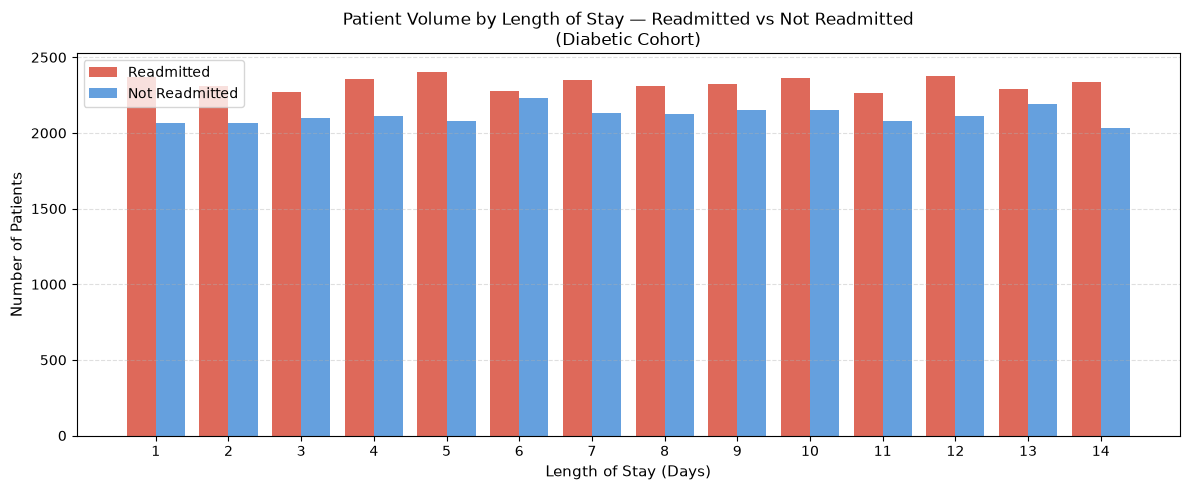

Chart saved.


In [15]:
readmitted = df_analysis[df_analysis['readmission_30'] == 1]['length_of_stay'].value_counts().sort_index()
not_readmitted = df_analysis[df_analysis['readmission_30'] == 0]['length_of_stay'].value_counts().sort_index()

days = sorted(df_analysis['length_of_stay'].unique())
width = 0.4

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar([d - width/2 for d in days],
       [readmitted.get(d, 0) for d in days],
       width=width, label='Readmitted', color='#d94f3d', alpha=0.85)
ax.bar([d + width/2 for d in days],
       [not_readmitted.get(d, 0) for d in days],
       width=width, label='Not Readmitted', color='#4a90d9', alpha=0.85)

ax.set_xlabel("Length of Stay (Days)", fontsize=11)
ax.set_ylabel("Number of Patients", fontsize=11)
ax.set_title("Patient Volume by Length of Stay — Readmitted vs Not Readmitted\n(Diabetic Cohort)", fontsize=12)
ax.set_xticks(days)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig("../models/patient_volume_by_los.png", dpi=150)
plt.show()
print("Chart saved.")